In [7]:
import random
import matplotlib.pyplot as plt
import numpy as np
import statistics
from collections import Counter

BA algorithm

In [8]:
def barabasi_albert_graph(N, m0, m):
    if m > m0:
        raise ValueError("m must be <= m0 for a valid initial network")

    def erdos_renyi_graph(m0, p):
        adjacency_list = {i: set() for i in range(m0)}
        for i in range(m0):
            for j in range(i + 1, m0):
                if random.random() < p:  # Edge exists with probability p
                    adjacency_list[i].add(j)
                    adjacency_list[j].add(i)
        return adjacency_list

    p = 0.5
    adjacency_list = erdos_renyi_graph(m0, p)
    nodes_list = [node for node in adjacency_list for _ in range(len(adjacency_list[node]))]

    for new_node in range(m0, N):
        targets = set()
        while len(targets) < m:
            targets.add(random.choice(nodes_list))

        adjacency_list[new_node] = targets
        for target in targets:
            adjacency_list[target].add(new_node)

        nodes_list.extend(targets)
        nodes_list.extend([new_node] * m)

    return adjacency_list

(a), (b), (c)

In [9]:
def average_clustering_coefficient(graph):
    clustering_coeffs = []
    for node in graph:
        neighbors = graph[node]
        if len(neighbors) < 2:
            clustering_coeffs.append(0)
            continue
        links = sum(1 for neighbor in neighbors for other in neighbors if other in graph[neighbor]) / 2
        clustering_coeffs.append(2 * links / (len(neighbors) * (len(neighbors) - 1)))
    return sum(clustering_coeffs) / len(clustering_coeffs)

def characteristic_path_length(graph):
    def bfs_shortest_path(start):
        queue = [(start, 0)]
        visited = {start}
        path_lengths = []
        while queue:
            node, length = queue.pop(0)
            path_lengths.append(length)
            for neighbor in graph[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append((neighbor, length + 1))
        return path_lengths

    all_lengths = []
    for node in graph:
        all_lengths.extend(bfs_shortest_path(node))
    return sum(all_lengths) / len(all_lengths)

def degree_distribution(graph):
    degrees = [len(neighbors) for neighbors in graph.values()]
    degree_counts = Counter(degrees)
    return degree_counts

In [ ]:
num_networks = 100  # Number of networks to generate
N = 200  # Total number of nodes per network
m0 = 5   # Size of initial network
m = 2    # Number of edges added per new node

 Feature                        | (Mean - Std deviation, Mean + Std deviation) 
--------------------------------|----------------------------------------------
 Average clustering coefficient | (0.0779 - 0.0211, 0.0779 + 0.0211)
 Characteristic path length     | (3.3539 - 0.0691, 3.3539 + 0.0691)


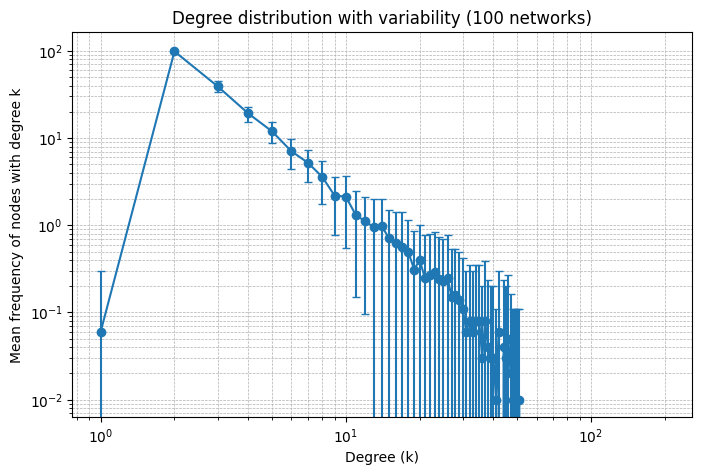

In [10]:
clustering_coeffs = []
path_lengths = []
degree_distributions = []

for _ in range(num_networks):
    G = barabasi_albert_graph(N, m0, m)
    clustering_coeffs.append(average_clustering_coefficient(G))
    path_lengths.append(characteristic_path_length(G))
    degree_distributions.append(degree_distribution(G))

mean_clustering = statistics.mean(clustering_coeffs)
std_clustering = statistics.stdev(clustering_coeffs)
mean_path_length = statistics.mean(path_lengths)
std_path_length = statistics.stdev(path_lengths)
print(" Feature                        | (Mean - Std deviation, Mean + Std deviation) ")
print("--------------------------------|----------------------------------------------")
print(f" Average clustering coefficient | ({mean_clustering:.4f} - {std_clustering:.4f}, {mean_clustering:.4f} + {std_clustering:.4f})")
print(f" Characteristic path length     | ({mean_path_length:.4f} - {std_path_length:.4f}, {mean_path_length:.4f} + {std_path_length:.4f})")


combined_degree_dist = Counter()
for dist in degree_distributions:
    combined_degree_dist.update(dist)

degree_vals = list(range(1, N))
degree_means = []
degree_stds = []

for k in degree_vals:
    freqs = [dist.get(k, 0) for dist in degree_distributions]
    if freqs:
        degree_means.append(statistics.mean(freqs))
        degree_stds.append(statistics.stdev(freqs) if len(freqs) > 1 else 0)
    else:
        degree_means.append(0)
        degree_stds.append(0)

plt.figure(figsize=(8, 5))
plt.errorbar(degree_vals, degree_means, yerr=degree_stds, fmt='o', linestyle='-', capsize=3)
plt.xlabel("Degree (k)")
plt.ylabel("Mean frequency of nodes with degree k")
plt.title("Degree distribution with variability (100 networks)")
plt.xscale("log")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()